# Lab: Building an Interactive Dashboard

In the lecture, we built a dashboard one piece at a time. In this lab, you will bring together the analysis workflow, Plotly figures, and Dash components to create an interactive dashboard using a dataset of your choosing.

Your dashboard should help a specific audience answer a focused question. The goal is not to fit every possible chart onto one page. Select a small set of related evidence, organize it clearly, and give the user one useful way to interact with it.



## Learning goals

By the end of this lab, you should be able to:

- use the reproducible analysis workflow to plan a dashboard;
- prepare and check data before displaying it;
- create Plotly figures that answer related questions;
- organize text, controls, and figures in a Dash layout;
- connect an interactive control to figures with a callback; and
- explain the conclusion and limitations of a dashboard.



## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding every part of the submitted work, testing the dashboard, citing the dataset, and checking that the evidence supports your conclusion. Do not submit private, confidential, or personally identifying data to an AI system.



## Assignment requirements

Choose a dataset that supports a meaningful comparison. It should contain:

- enough observations to reveal a pattern rather than a few isolated cases;
- at least one categorical feature that can be used as an interactive filter or comparison;
- at least two additional useful features, which may be categorical, quantitative, temporal, spatial, or text-derived; and
- enough documentation for you to explain what the records and selected features represent.

The completed dashboard must contain:

- a descriptive title and a short explanation of its purpose;
- at least two related Plotly figures;
- at least one dropdown menu or radio-button control;
- at least one callback that updates both figures;
- human-readable titles, labels, categories, and colors;
- stable axes or category orders when changing them would make comparisons misleading; and
- a brief conclusion and limitation displayed on the page.



# Step 1: Question



## 1. Identify the audience

A dashboard should be designed for someone. Identify a realistic audience and explain what decision, judgment, or understanding the dashboard could support.



**Who is the intended audience, and why would this evidence be useful to them?**

A game publisher's planning team deciding which regions and release timing to prioritize for a genre. Seeing how a genre sells by region and over time helps them target marketing and plan releases.

## 2. State the research question

Write one focused question that your two figures will help answer. The question should name the main features or groups being compared.



**What question will the dashboard answer?**

For a selected game genre, how do total sales break down across regions, and how did global sales for that genre change over time.

## 3. Make a prediction



**What pattern do you expect to find, and what informed that prediction?**

I expect North America to be the largest market for most genres and global sales to peak in the late 2000s. Prior labs with this data showed North America leading, and the dataset's releases thin out after that period.

# Step 2: Data



## 4. Import the libraries

Import Pandas, Plotly Express, and the Dash objects used in the lecture: `Dash`, `dcc`, `html`, `Input`, and `Output`.



In [2]:
%pip install dash

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ------------------------------ --------- 6.8/8.9 MB 39.6 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 38.7 MB/s  0:00:00

   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   ------

In [3]:
import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

## 5. Document the dataset

Give the dataset title, its creator or publisher, a working link or citation, the time period represented, and any relevant collection or sampling information.



**Where did the data come from, and what does its documentation tell you about how it was collected?**

The data is the "Video Games Sales" dataset by elis3e on Kaggle (https://www.kaggle.com/datasets/elis3e/video-games-sales). Each record has a game's platform, year, genre, and publisher, plus sales in millions of units by region and global total. The figures are compiled estimates covering tracked titles, so they are approximate.

## 6. Read the data

Read the dataset into a Pandas DataFrame. Give the DataFrame a short, descriptive name.



In [4]:
vgsales = pd.read_csv("data/vgsales.csv")

## 7. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.



In [5]:
display(vgsales.head())
display(vgsales.tail())
vgsales.info()
vgsales.isnull().sum()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,259,Asteroids,2600,1980,Shooter,Atari,4.00,0.26,0.0,0.05,4.31
1,545,Missile Command,2600,1980,Shooter,Atari,2.56,0.17,0.0,0.03,2.76
2,1768,Kaboom!,2600,1980,Misc,Activision,1.07,0.07,0.0,0.01,1.15
3,1971,Defender,2600,1980,Misc,Atari,0.99,0.05,0.0,0.01,1.05
4,2671,Boxing,2600,1980,Fighting,Activision,0.72,0.04,0.0,0.01,0.77


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16319,16565,Mighty No. 9,XOne,2016,Platform,Deep Silver,0.01,0.00,0.00,0.0,0.01
16320,16572,Resident Evil 4 HD,XOne,2016,Shooter,Capcom,0.01,0.00,0.00,0.0,0.01
16321,16573,Farming 2017 - The Simulation,PS4,2016,Simulation,UIG Entertainment,0.00,0.01,0.00,0.0,0.01
16322,16579,Rugby Challenge 3,XOne,2016,Sports,Alternative Software,0.00,0.01,0.00,0.0,0.01
16323,16592,Chou Ezaru wa Akai Hana: Koi wa Tsuki ni Shiru...,PSV,2016,Action,dramatic create,0.00,0.00,0.01,0.0,0.01


<class 'pandas.DataFrame'>
RangeIndex: 16324 entries, 0 to 16323
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16324 non-null  int64  
 1   Name          16324 non-null  str    
 2   Platform      16324 non-null  str    
 3   Year          16324 non-null  int64  
 4   Genre         16324 non-null  str    
 5   Publisher     16288 non-null  str    
 6   NA_Sales      16324 non-null  float64
 7   EU_Sales      16324 non-null  float64
 8   JP_Sales      16324 non-null  float64
 9   Other_Sales   16324 non-null  float64
 10  Global_Sales  16324 non-null  float64
dtypes: float64(5), int64(2), str(4)
memory usage: 2.1 MB


Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

**Complete the table for every feature you expect to use. Add or remove rows as needed.**

| Feature | What it represents | Data storage type | Feature type | Missing values | Dashboard role |
|---|---|---|---|---:|---|
| Genre | Game's Category | str | Categorical | 0 | Dropdown Control |
| Year | Release Year | int64 | Temporal | 0 | X-axis of Figure1 |
| Global_Sales | Worldwide Sales | float64 | Quantitative | 0 | Y-axis of Figure1 |
| NA_Sales | North America Sales | float64 | Quantitative | 0 | Figure2 |
| EU_Sales | Europe Sales | float64 | Quantitative | 0 | Figure2 |
| JP_Sales | Japan Sales | float64 | Quantitative | 0 | Figure2 |
| Other_Sales | Other-region Sales | float64 | Quantitative | 0 | Figure2 |



**What does one row of the original dataset represent?**

One game release on one platform, with its sales in millions of units by region and worldwide.

# Step 3: Operation



## 8. Create the analysis DataFrame

Select the features needed for the dashboard and use `.copy()` to create a DataFrame named `analysis`. Handle missing values in a way that is appropriate for the question. If values need clearer labels or corrected storage types, make those changes here.



In [6]:
analysis = vgsales[["Genre", "Year", "Global_Sales", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].copy()

**How did you handle missing values, and why was that choice appropriate?**

No missing values needed handling. All seven features I use are complete, and the 36 missing Publisher values are in a column the dashboard does not use.

## 9. Create any calculated features

If the dashboard needs a calculated category, date component, percentage, rate, or other calculated feature, create it here. If no calculated feature is needed, leave the code cell blank and explain why.



In [7]:
region_labels = {
    "NA_Sales": "North America",
    "EU_Sales": "Europe",
    "JP_Sales": "Japan",
    "Other_Sales": "Other"
}

**What calculated feature or cleaned label did you create, and how will it support the dashboard?**

I created a mapping of the raw region column names to readable labels. It makes the region bar chart understandable to someone who has not seen the column names.

## 10. Prepare the control options

Create the labels and values for the dropdown or radio-button control. The visible labels should be understandable to someone who has not seen the original column names.



In [8]:
genre_options = [{"label": genre, "value": genre} for genre in sorted(analysis["Genre"].unique())]

# Step 4: Check



## 11. Check the prepared data

Display the first rows of `analysis`, its stored data types, missing-value counts, and appropriate summaries or frequency counts for the dashboard features.



In [9]:
display(analysis.head())
print(analysis.dtypes)
print()
print(analysis.isnull().sum())
print()
analysis[["Global_Sales", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].describe()

,Genre,Year,Global_Sales,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,Shooter,1980,4.31,4.00,0.26,0.0,0.05
1,Shooter,1980,2.76,2.56,0.17,0.0,0.03
2,Misc,1980,1.15,1.07,0.07,0.0,0.01
3,Misc,1980,1.05,0.99,0.05,0.0,0.01
4,Fighting,1980,0.77,0.72,0.04,0.0,0.01


Genre               str
Year              int64
Global_Sales    float64
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
dtype: object

Genre           0
Year            0
Global_Sales    0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
dtype: int64



,Global_Sales,NA_Sales,EU_Sales,JP_Sales,Other_Sales
count,16324.000000,16324.000000,16324.000000,16324.000000,16324.000000
mean,0.540328,0.265464,0.147581,0.078673,0.048334
std,1.565860,0.821658,0.508809,0.311584,0.189902
min,0.010000,0.000000,0.000000,0.000000,0.000000
25%,0.060000,0.000000,0.000000,0.000000,0.000000
50%,0.170000,0.080000,0.020000,0.000000,0.010000
75%,0.480000,0.240000,0.110000,0.040000,0.040000
max,82.740000,41.490000,29.020000,10.220000,10.570000


## 12. Check the interactive groups

Calculate the number of observations available for every control option. Make sure each option returns data and that unexpectedly small groups are understood before building the callback.



In [10]:
analysis["Genre"].value_counts()

Genre
Action          3252
Sports          2304
Misc            1710
Role-Playing    1469
Shooter         1282
Adventure       1276
Racing          1226
Platform         876
Simulation       851
Fighting         836
Strategy         671
Puzzle           571
Name: count, dtype: int64

**What did these checks establish about the data that will appear in the dashboard?**

The prepared data is complete, with no missing values and correct types. All twelve genres have enough games to plot, ranging from Action down to Puzzle. So every dropdown option returns real data with no empty or unusably small groups.

# Step 5: Evidence



## 13. Create the first static Plotly figure

Build the first figure before placing it in Dash. Give it a descriptive title and human-readable axis and legend labels.



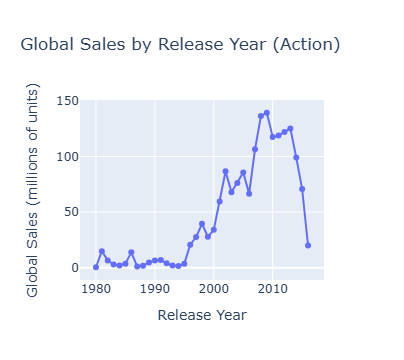

In [11]:
action = analysis[analysis["Genre"] == "Action"]
yearly = action.groupby("Year")["Global_Sales"].sum().reset_index()

fig1 = px.line(yearly, x="Year", y="Global_Sales", markers=True,
              title="Global Sales by Release Year (Action)",
              labels={"Year": "Release Year", "Global_Sales": "Global Sales (millions of units)"})
fig1.show()

**What evidence should a viewer obtain from the first figure?**

How total global sales for the selected genre rose and fell over time, showing which years the genre sold best.

## 14. Create the second static Plotly figure

The second figure should add different but related evidence rather than repeat the first figure in another style.



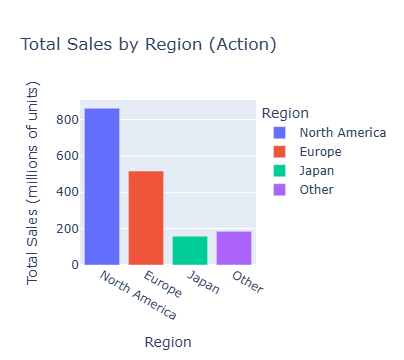

In [12]:
region_totals = pd.DataFrame({"Region": ["North America", "Europe", "Japan", "Other"],
                             "Sales": [
                                 action["NA_Sales"].sum(),
                                 action["EU_Sales"].sum(),
                                 action["JP_Sales"].sum(),
                                 action["Other_Sales"].sum()
                             ]})
fig2 = px.bar(region_totals, x="Region", y="Sales", color="Region",
             title="Total Sales by Region (Action)",
             labels={"Sales": "Total Sales (millions of units)"})
fig2.show()

**What does the second figure add to the first figure's evidence?**

It shows where the genre sold, breaking total sales into the four regions, while figure 1 only shows sales over time. Together they answer both when and where the genre sold.

## 15. Plan the dashboard



**Complete the dashboard plan before writing the app. Add rows if needed.**

| Component | What it displays or controls | Why it belongs on the dashboard |
|---|---|---|
| Title and introduction | Dashboard title and a sentence naming the audience and question| Tells the viewer what the dashboard is for |
| Interactive control | Dropdown to select a game genre | Lets the user focus the evidence on one genre at a time |
| First figure | Line chart of global sales by release year for the selected genre | Shows when the genre sold best over time |
| Second figure | Bar chart of total sales by region for the selected genre | Shows where the genre sold across the four regions |
| Conclusion and limitation | Short statements answering the question and noting the data's limits | Helps the viewer interpreted the evidence correctly |



## 16. Create reusable figure code

Write a function that accepts the selected control value, filters or summarizes `analysis`, creates both Plotly figures, and returns the figures in a consistent order. Fix axis ranges or category orders when they need to remain stable across selections.



In [20]:
region_order = ["North America", "Europe", "Japan", "Other"]
region_colors = {
    "North America": "#636EFA",
    "Europe": "#EF553B",
    "Japan": "#00CC96",
    "Other": "#AB63FA",
}

year_min = analysis["Year"].min()
year_max = analysis["Year"].max()
sales_max = analysis.groupby(["Genre", "Year"])["Global_Sales"].sum().max()

def build_figures(genre):
    subset = analysis[analysis["Genre"] == genre]

    yearly = subset.groupby("Year")["Global_Sales"].sum().reset_index()
    fig1 = px.line(yearly, x="Year", y="Global_Sales", markers=True,
                   title=f"Global Sales by Release Year ({genre})",
                   labels={"Year": "Release year", "Global_Sales": "Global sales (millions of units)"})
    fig1.update_xaxes(range=[year_min - 1, year_max + 1])
    fig1.update_yaxes(range=[0, sales_max * 1.05])

    region_totals = pd.DataFrame({
        "Region": region_order,
        "Sales": [
            subset["NA_Sales"].sum(),
            subset["EU_Sales"].sum(),
            subset["JP_Sales"].sum(),
            subset["Other_Sales"].sum(),
        ],
    })
    fig2 = px.bar(region_totals, x="Region", y="Sales", color="Region",
                  category_orders={"Region": region_order},
                  color_discrete_map=region_colors,
                  title=f"Total Sales by Region ({genre})",
                  labels={"Sales": "Total sales (millions of units)"})

    return fig1, fig2

## 17. Build the layout

Create a Dash app and its layout. Include the title, purpose statement, interactive control, two empty `dcc.Graph` components with unique IDs, and short conclusion and limitation statements.



In [21]:
app = Dash(__name__)

app.layout = html.Div([
    html.H1("Video Game Sales by Genre"),
    html.P("For a selected game genre, this dashboard shows how global sales changed over time and how sales break down by region. Audience: a publisher's planning team weighing where and when to focus a genre."),

    html.Label("Select a genre:"),
    dcc.Dropdown(id="genre-dropdown", options=genre_options, value="Action", clearable=False),

    dcc.Graph(id="sales-by-year"),
    dcc.Graph(id="sales-by-region"),

    html.H3("Conclusion"),
    html.P("Across genres, North America is usually the largest market and global sales for most genres peaked in the late 2000s before declining. Use the dropdown to compare how strongly this holds for each genre."),

    html.H3("Limitation"),
    html.P("These are estimated sales for tracked titles only, and the dataset thins out in its final years, so the recent drop reflects incomplete data rather than a true collapse in sales."),
])

## 18. Connect the callback

Connect the control's `value` to the `figure` property of both graphs. The callback function should call the reusable figure function and return its two figures in the same order as the two outputs.



In [22]:
@app.callback(
    Output("sales-by-year", "figure"),
    Output("sales-by-region", "figure"),
    Input("genre-dropdown", "value"),
)
def update_figures(selected_genre):
    return build_figures(selected_genre)

## 19. Check the callback as a Python function

Call the callback or reusable figure function with at least two valid control values. Confirm that each call returns two Plotly figures without an error.



In [23]:
for test_genre in ["Action", "Puzzle"]:
    f1, f2 = update_figures(test_genre)
    print(f"{test_genre}: returned {type(f1).__name__} and {type(f2).__name__}")

Action: returned Figure and Figure
Puzzle: returned Figure and Figure


In [24]:
app.run(debug=True, port=8050)

## 20. Run the dashboard

Run the app in a browser tab. Use a port that is not already occupied by another app, and stop the app before restarting the same code.



**After testing every control option, what did you revise or confirm about the dashboard's behavior?**

I confirmed that selecting any genre updates both charts together and that every genre returns data. The fixed y-axis and region order stay constant across selections, so genres can be compared honestly.

**Which design choice most improves the dashboard's readability or usefulness?**

Locking the line chart's y-axis and the region order and colors across genres. It keeps every selection on the same scale, so differences between genres are real rather than an artifact of auto-scaling.

# Step 6: Conclusion



**State a concise conclusion that directly answers the research question and refers to evidence visible in the dashboard.**

For a selected genre, the dashboard shows that global sales grew through the 2000s and peaked in the late 2000s to early 2010s before falling, and that North America is usually the largest market, followed by Europe. The pattern holds for big genres like Action and Shooter, while smaller genres such as Puzzle stay low on the same scale.

**How does the interactive control help the audience examine the evidence?**

The genre dropdown lets the user compare one genre at a time across both charts at once. Because the axes and region order stay fixed, switching genres shows real differences in size and timing rather than rescaled views.

# Step 7: Limitation



**State one important limitation on how the dashboard's evidence should be interpreted.**

The sales figures are estimates for tracked titles only, and the dataset thins out in its final years. The recent drop in every genre reflects incomplete data, not a true collapse in sales, so it should not be read as a real market decline.

## AI-use reflection



**Describe any AI assistance you used. Identify one suggestion you verified, revised, or rejected. If you did not use AI, state that.**

Yes, I used Claude AI to help plan the dashboard, check code, and talk through the answers. One thing I verified was fixing the line chart's y-axis to the busiest genre-year so genres stay comparable across selections. I tested the dashboard myself and checked the figures against the data.

## Submission checklist

Before submitting, confirm that:

- [x] every prompt has one complete response;
- [x] all notebook cells run in order without an error;
- [x] the dashboard opens and every control option works;
- [x] the two figures use readable titles, labels, categories, and colors;
- [x] comparable views retain stable axes or category orders when needed;
- [x] the dataset source is cited and the required data file accompanies the submission;
- [x] the notebook and dashboard code are organized and readable;
- [x] the conclusion and limitation are supported by the displayed evidence; and
- [x] the work is submitted by the deadline.

